In [1]:
!pip install supervision
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.7 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.3 MB/s eta 0:00:00:00:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

# **Yolo**

# mothodes for yolo

In [2]:
 
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
import supervision as sv
from roboflow import Roboflow
from PIL import Image, ImageOps
import seaborn as sns
import math
from matplotlib import cm
sns.set_palette("husl")
import numpy as np
import supervision as sv


def filter_best_detections(detections: sv.Detections) -> sv.Detections:
    """
    فقط بهترین دتکشن برای هر کلاس را نگه می‌دارد:
    1. اگر برای یک باکس چند کلاس مختلف بود → فقط بالاترین confidence.
    2. اگر برای یک کلاس چند دتکشن مختلف بود → فقط بالاترین confidence.
    """

    filtered = []
    used_boxes = set()

    # --- مرحله ۱: انتخاب بهترین دتکشن برای هر باکس ---
    for mask, class_id, conf, box in zip(
        detections.mask, detections.class_id, detections.confidence, detections.xyxy
    ):
        box_key = tuple(map(int, box))
        if box_key not in used_boxes:
            # همه‌ی دتکشن‌هایی که روی همین باکس افتاده‌اند
            same_box = [
                (m, c, cf, b)
                for m, c, cf, b in zip(
                    detections.mask, detections.class_id, detections.confidence, detections.xyxy
                )
                if tuple(map(int, b)) == box_key
            ]
            # انتخاب بهترین بر اساس confidence
            best = max(same_box, key=lambda x: x[2])
            filtered.append(best)
            used_boxes.add(box_key)

    # --- مرحله ۲: انتخاب بهترین دتکشن برای هر کلاس ---
    best_per_class = {}
    for m, c, cf, b in filtered:
        if c not in best_per_class or cf > best_per_class[c][2]:
            best_per_class[c] = (m, c, cf, b)

    final = list(best_per_class.values())

    return sv.Detections(
        xyxy=np.array([b for (_, _, _, b) in final]),
        mask=np.array([m for (m, _, _, _) in final]),
        class_id=np.array([c for (_, c, _, _) in final]),
        confidence=np.array([cf for (_, _, cf, _) in final])
    )

    
# def filter_best_detections(detections: sv.Detections) -> sv.Detections:
#     """
#     فقط بهترین کلاس (با بالاترین confidence) را برای هر آبجکت نگه می‌دارد.
#     """
#     filtered = []
#     used_boxes = set()

#     # روی همه‌ی دتکشن‌ها لوپ می‌زنیم
#     for mask, class_id, conf, box in zip(
#         detections.mask, detections.class_id, detections.confidence, detections.xyxy
#     ):
#         box_key = tuple(map(int, box))
#         if box_key not in used_boxes:
#             # همه‌ی دتکشن‌هایی که روی همین باکس افتاده‌اند
#             same_box = [
#                 (m, c, cf, b)
#                 for m, c, cf, b in zip(
#                     detections.mask, detections.class_id, detections.confidence, detections.xyxy
#                 )
#                 if tuple(map(int, b)) == box_key
#             ]
#             # انتخاب بهترین بر اساس confidence
#             best = max(same_box, key=lambda x: x[2])
#             filtered.append(best)
#             used_boxes.add(box_key)

    # # بازسازی دتکشن نهایی
    # return sv.Detections(
    #     xyxy=np.array([b for (_, _, _, b) in filtered]),
    #     mask=np.array([m for (m, _, _, _) in filtered]),
    #     class_id=np.array([c for (_, c, _, _) in filtered]),
    #     confidence=np.array([cf for (_, _, cf, _) in filtered])
    # )
    
def max_by_abs(arr):
    best = arr[0]
    best_abs = abs(arr[0])
    for i in range(1, len(arr)):
        a = abs(arr[i])
        if a > best_abs:
            best = arr[i]
            best_abs = a
    return best
    
def getangle(image, output_path):
    # 1. Load image
    # image = cv2.imread(image)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    # 2. Preprocessing
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150, apertureSize=3)
    
    # 3. Detect lines with fallback
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=100,
        minLineLength=100,
        maxLineGap=10
    )
    
    # If no lines detected, try alternative parameters
    if lines is None:
        print("No lines detected with standard parameters, trying alternatives...")
        edges = cv2.Canny(blur, 30, 100)  # Lower thresholds
        lines = cv2.HoughLinesP(
            edges,
            rho=1,
            theta=np.pi/180,
            threshold=50,  # Lower threshold
            minLineLength=50,  # Shorter minimum length
            maxLineGap=20
        )
    
    # If still no lines, return original image
    if lines is None:
        print("Warning: No lines detected - returning original image")
        cv2.imwrite(output_path, image)
        return 0.0  # Return 0 angle
    
    # 4. Calculate angles (both horizontal and vertical lines)
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
        # Include both horizontal and vertical lines for skew detection
        if abs(angle) < 45 or abs(angle - 90) < 45:  # Detect both near-horizontal and near-vertical lines
            angles.append(angle)
    
    # If no good angles found, return original
    if not angles:
        print("Warning: No suitable angles found - returning original image")
        cv2.imwrite(output_path, image)
        return 0.0
    
    # 5. Calculate median angle
    median_angle = np.median(angles)
    print(f"Detected rotation angle: {median_angle:.2f} degrees")
     
    return median_angle  # Return angle for debugging or further processing



# Correct skew with the correct negative angle and rotate to the right
def correct_skew_with_negative_angle(image, angle):
    if angle<0: 
        angle=-angle
    if image is None:
        raise ValueError("Image is empty.")
    
    print(f"Correcting image with angle: {angle} degrees")

    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, -angle, 1.0)  # Negative angle directly for right rotation
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    
    
    return rotated, angle


def plot_detailed_segments(image, detections, classes):
    """Plot each segment individually with its mask"""
    num_detections = len(detections)
    cols = 3  # Number of columns in subplot
    rows = int(np.ceil((num_detections + 1) / cols))
    
    plt.figure(figsize=(cols*10, rows*10))
    
    # Original image
    plt.subplot(rows, cols, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')
    
    # Each detection
    for i, (mask, class_id, confidence) in enumerate(zip(
        detections.mask, detections.class_id, detections.confidence
    )):
        if mask is None:
            continue
            
        plt.subplot(rows, cols, i+2)
        
        # Apply mask
        segmented = cv2.bitwise_and(image, image, mask=(mask*255).astype(np.uint8))
        
        # Plot
        plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
        plt.title(f"{classes[class_id]}\nConf: {confidence:.2f}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


def resize_image(image_path, output_path, max_size=2048):
    img = Image.open(image_path)
    img = ImageOps.exif_transpose(img)   # این خط باعث میشه عکس طبق orientation اصلی بچرخه
    img.thumbnail((max_size, max_size))
    img.save(output_path)

# def loadyolotextlocation(v,classes=['birthday','exp','fathername','idcard','idnumber','img','lastname','name'],api_key="XNjXPo3HTc0NFRVrH8Kz",pn="idcardsegmentation-gz97d"):
def loadyolotextlocation(v,classes ,api_key,pn):
    # Initialize Roboflow segmentation model
    rf = Roboflow(api_key)
    project = rf.workspace().project(pn)
    version = project.version(v)
    model = version.model
    return model,classes

def textcropped_backup(model,input_path,output_crops_dir="segmented_crops",confidence=10):
    # Configurations
    # output_crops_dir = "/kaggle/working/segmented_crops"
    # Get predictions
    # output_crops_dir="segmented_crops"
    os.makedirs(output_crops_dir, exist_ok=True)
    # Paths
    # input_path = "/kaggle/input/iranian-national-id-card-dataset/sample3.jpg"
    # resized_path = "/kaggle/working/resized_sample.jpg"
    resized_path = "resized_sample.jpg"
    resize_image(input_path, resized_path)
    
    # result = model.predict(resized_path, confidence=50).json()
    result = model.predict(input_path, confidence).json()
    detections = sv.Detections.from_inference(result) 
    detections=filter_best_detections(detections)
    
    # Load image
    image = cv2.imread(resized_path)
    # image0 = cv2.imread(input_path)
    height, width = image.shape[:2] 
    
    # angle = getangle(image,  'corrected_image.jpg')  # Your manually calculated angle
    # angle=getangle_minAreaRect(image)
    angle=getangle(image, 'corrected_image.jpg')
    # angle=getangle_hough(image)
    # if angle>0: 
    #     angle=-angle
    rotated_image_final_corrected, final_angle_corrected = correct_skew_with_negative_angle(image, angle)
    cv2.imwrite('a.jpg', rotated_image_final_corrected)
    plt.imshow(rotated_image_final_corrected)
    plt.title("image")
    plt.axis('off')
    plt.show()
    
    # Process each segmentation mask
    # image=rotated_image_final_corrected
    angels=[] 
    a1=0
    # Main loop handling image processing
    for i, (mask, class_id, confidence) in enumerate(zip(detections.mask, detections.class_id, detections.confidence)):
        if mask is None:
            print('mask is empty')
            continue
        
        class_name = classes[class_id] if class_id is not None else f"unknown_{i}"
        # binary_mask = (mask * 255).astype(np.uint8)
        # segmented_region = cv2.bitwise_and(image, image, mask=binary_mask)
        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask[:, :, 0]
        
        # اطمینان از اینکه ماسک uint8 است و مقدار 0 یا 255 دارد
        if mask.dtype != np.uint8:
            mask = (mask * 255).astype(np.uint8)
        else:
            if mask.max() <= 1:
                mask = mask * 255
        
        binary_mask = mask  # (H, W)، dtype uint8
        
        # اطمینان از تطابق اندازه
        assert binary_mask.shape == image.shape[:2], "Mask size must match image size"
        
        segmented_region = cv2.bitwise_and(image, image, mask=binary_mask)
            
        y_indices, x_indices = np.where(mask)
        if len(x_indices) == 0 or len(y_indices) == 0:
            continue
            
        x1, y1 = np.min(x_indices), np.min(y_indices)
        x2, y2 = np.max(x_indices), np.max(y_indices)
        print("class_name     :::",class_name)
        if class_name != "idcard" and class_name != "img": #if class_name not in {"idcard", "img"}:
         print("hhhhhhhhhhhhhhiiiiiiiiiiiiiiiii")
         if y1-100 > 0 and y2+100 < height and x1-100 > 0 and x2+100 < width:
            cropped = segmented_region[y1-100:y2+100, x1-100:x2+100]
            print("padding")
         else:
            cropped = segmented_region[y1:y2, x1:x2]
            print('with paddd')  
        else:
            cropped = segmented_region[y1:y2, x1:x2]
            print('with paddd')
        
        # output_path = os.path.join(output_crops_dir, f"{class_name}_{class_id}.png")
        output_path = os.path.join(output_crops_dir, f"{class_name}.png")
        print('----------------------')
        print(output_path)
        # Skip if image is empty
        if cropped is None:
            print(f"Skipping empty cropped region for {class_name}.")
            print('croppp is none')
            continue
        if  cropped.size == 0:
            print(f"Skipping empty cropped region for {class_name}.")
            print("size 00000000000")
        # Correct skew only if necessary
        # angle = correct_skew(cropped, output_path)
        # print('class_name:',class_name)
        
        angle = getangle(cropped, output_path)  # Your manually calculated angle
        # angle=getangle_minAreaRect(image)
        # angle=getangle_hough(image)
        if class_name == "idnumber":
            a1=angle
        angels.append(abs(angle))
        # print('angle_to_correct:',angle)
        a=max_by_abs(angels)
        # print('max angel',a)
        rotated_image_final_corrected, final_angle_corrected = correct_skew_with_negative_angle(cropped, a)
        cv2.imwrite(output_path, rotated_image_final_corrected)
        # if abs(angle) < 1:
        #     print(f"Skipping skew correction for {class_name} as the angle is minimal.")
    
        plt.imshow(rotated_image_final_corrected)
        plt.title("...")
        plt.axis('off')
        plt.show()
        
        
    
    # Visualize all masks (optional)
    mask_annotator = sv.MaskAnnotator()
    annotated_image = mask_annotator.annotate(
        scene=image.copy(),
        detections=detections
    )
    
    label_annotator = sv.LabelAnnotator()
    annotated_image = label_annotator.annotate(
        scene=annotated_image,
        detections=detections,
        labels=[f"{classes[class_id]}" 
               for class_id, conf in zip(detections.class_id, detections.confidence)]
    )
    
    cv2.imwrite("annotated_segmentation.jpg", annotated_image)
    print(f"Saved {len(detections)} segmented crops to {output_crops_dir}")
    
    
    #/////////
    # image1 = cv2.imread("/kaggle/working/")
    # # image0 = cv2.imread(input_path)
    # height1, width1 = image1.shape[:2]
    
    # Create a combined mask where all segments are white (255) and background is black (0)
    combined_mask = np.zeros((height, width), dtype=np.uint8)
    
    for (mask,clid) in zip(detections.mask,detections.class_id):
        if clid != 3:
            if mask is not None:
                combined_mask[mask] = 255  # Set all segments to white
    
    # Save the combined mask
    mask_path = 'combined_mask.png'
    cv2.imwrite(mask_path, combined_mask)
    print(f"Saved combined mask to {mask_path}")
    
    # Optional: Visualize the combined mask
    plt.imshow(combined_mask, cmap='gray')
    plt.title("Combined Mask (White=Segments, Black=Background)")
    plt.axis('off')
    plt.show()


    return image, detections,a1


In [3]:
!python --version

Python 3.11.13


In [5]:
import os
import cv2
import matplotlib.pyplot as plt
import supervision as sv

def textcropped(model, input_path, output_crops_dir="segmented_crops", visualize=True,confidence=10):
    """
    پردازش کارت ملی: تشخیص فیلدها، کراپ و ذخیره.
    
    ورودی:
        model: مدل segment
        input_path: مسیر تصویر ورودی
        output_crops_dir: مسیر ذخیره‌ی خروجی‌ها
        visualize: اگر True باشد، نتایج نمایش داده می‌شوند
    
    خروجی:
        dict شامل نام فیلد → مسیر فایل ذخیره‌شده
    """
    os.makedirs(output_crops_dir, exist_ok=True)

    resized_path = "resized_sample.jpg"
    resize_image(input_path, resized_path)

    # پیش‌بینی مدل
    result = model.predict(resized_path, confidence).json()
    detections = sv.Detections.from_inference(result)
    detections = filter_best_detections(detections)

    # خواندن تصویر
    image = cv2.imread(resized_path)
    height, width = image.shape[:2]

    # تصحیح زاویه کلی کارت
    angle = getangle(image, 'corrected_image.jpg')
    rotated_image_final_corrected, final_angle_corrected = correct_skew_with_negative_angle(image, angle)
    cv2.imwrite('a.jpg', rotated_image_final_corrected)

    if visualize:
        plt.imshow(rotated_image_final_corrected)
        plt.title("Corrected Card")
        plt.axis('off')
        plt.show()

    results = {}
    angels = []
    a1 = 0
    #///////////////////////////////////////
    # پردازش ماسک‌ها
    for i, (mask, class_id, confidence) in enumerate(zip(detections.mask, detections.class_id, detections.confidence)):
        if mask is None:
            print('⚠️ mask is empty')
            continue

        class_name = classes[class_id] if class_id is not None else f"unknown_{i}"

        # تبدیل ماسک به (H, W)
        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask[:, :, 0]

        # اطمینان از uint8 بودن و مقادیر 0/255
        if mask.dtype != np.uint8:
            mask = (mask * 255).astype(np.uint8)
        elif mask.max() <= 1:
            mask = mask * 255

        binary_mask = mask

        # ✅ یکسان‌سازی سایز ماسک با تصویر
        if binary_mask.shape != image.shape[:2]:
            print(f"⚠️ Resizing mask from {binary_mask.shape} to {image.shape[:2]}")
            binary_mask = cv2.resize(binary_mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

        assert binary_mask.shape == image.shape[:2], "Mask size must match image size"

        # اعمال ماسک روی تصویر
        segmented_region = cv2.bitwise_and(image, image, mask=binary_mask)

        # پیدا کردن مختصات ناحیه ماسک
        y_indices, x_indices = np.where(binary_mask > 0)
        if len(x_indices) == 0 or len(y_indices) == 0:
            continue

        x1, y1 = np.min(x_indices), np.min(y_indices)
        x2, y2 = np.max(x_indices), np.max(y_indices)

        if class_name not in {"idcard", "img"}:
            if y1-100 > 0 and y2+100 < height and x1-100 > 0 and x2+100 < width:
                cropped = segmented_region[y1-100:y2+100, x1-100:x2+100]
                print(f"✅ Cropped with padding for {class_name}")
            else:
                cropped = segmented_region[y1:y2, x1:x2]
                print(f"✅ Cropped without padding for {class_name}")
        else:
            cropped = segmented_region[y1:y2, x1:x2]

        output_path = os.path.join(output_crops_dir, f"{class_name}.png")

        if cropped is None or cropped.size == 0:
            print(f"⚠️ Skipping empty cropped region for {class_name}.")
            continue

        # زاویه فیلد
        angle = getangle(cropped, output_path)
        if class_name == "idnumber":
            a1 = angle
        angels.append(abs(angle))
        a = max_by_abs(angels)

        # تصحیح زاویه
        rotated_crop, final_angle_corrected = correct_skew_with_negative_angle(cropped, a)
        cv2.imwrite(output_path, rotated_crop)
        results[class_name] = output_path

        if visualize:
            plt.imshow(rotated_crop)
            plt.title(class_name)
            plt.axis('off')
            plt.show()

    #///////////////////////////////////

    
    # Visualize all masks (optional)
    mask_annotator = sv.MaskAnnotator()
    annotated_image = mask_annotator.annotate(
        scene=image.copy(),
        detections=detections
    )
    
    label_annotator = sv.LabelAnnotator()
    annotated_image = label_annotator.annotate(
        scene=annotated_image,
        detections=detections,
        labels=[f"{classes[class_id]}" 
               for class_id, conf in zip(detections.class_id, detections.confidence)]
    )
    
    cv2.imwrite("annotated_segmentation.jpg", annotated_image)
    print(f"Saved {len(detections)} segmented crops to {output_crops_dir}")
    
    
    #/////////
    # image1 = cv2.imread("/kaggle/working/")
    # # image0 = cv2.imread(input_path)
    # height1, width1 = image1.shape[:2]
    
    # Create a combined mask where all segments are white (255) and background is black (0)
    combined_mask = np.zeros((height, width), dtype=np.uint8)
    
    for (mask,clid) in zip(detections.mask,detections.class_id):
        if clid != 3:
            if mask is not None:
                combined_mask[mask] = 255  # Set all segments to white
    
    # Save the combined mask
    mask_path = 'combined_mask.png'
    cv2.imwrite(mask_path, combined_mask)
    print(f"Saved combined mask to {mask_path}")
    
    # Optional: Visualize the combined mask
    plt.imshow(combined_mask, cmap='gray')
    plt.title("Combined Mask (White=Segments, Black=Background)")
    plt.axis('off')
    plt.show()


    # return image, detections,a1        

    return results


In [6]:
def textcroppedidcard(model,input_path,output_crops_dir="segmented_cropsidcard"):
    os.makedirs(output_crops_dir, exist_ok=True)
    resized_path = "resized_sample.jpg"
    resize_image(input_path, resized_path)
    
    result = model.predict(resized_path, confidence=10).json()
    # result = model.predict(input_path, confidence=50).json()
    detections = sv.Detections.from_inference(result)
    detections=filter_best_detections(detections)
    
    # Load image
    image = cv2.imread(resized_path)
    # image0 = cv2.imread(input_path)
    height, width = image.shape[:2] 
    a1=0
    for i, (mask, class_id, confidence) in enumerate(zip(detections.mask, detections.class_id, detections.confidence)):
        if mask is None:
            print('mask is empty')
            continue
        
        class_name = classes[class_id] if class_id is not None else f"unknown_{i}"
        if class_name=="idcard":
            # binary_mask = (mask * 255).astype(np.uint8)
            # segmented_region = cv2.bitwise_and(image, image, mask=binary_mask)
            if mask.ndim == 3 and mask.shape[-1] == 1:
                mask = mask[:, :, 0]
            
            # اطمینان از اینکه ماسک uint8 است و مقدار 0 یا 255 دارد
            if mask.dtype != np.uint8:
                mask = (mask * 255).astype(np.uint8)
            else:
                if mask.max() <= 1:
                    mask = mask * 255
            
            binary_mask = mask  # (H, W)، dtype uint8
            
            # اطمینان از تطابق اندازه
            assert binary_mask.shape == image.shape[:2], "Mask size must match image size"
            
            segmented_region = cv2.bitwise_and(image, image, mask=binary_mask)
                
            y_indices, x_indices = np.where(mask)
            if len(x_indices) == 0 or len(y_indices) == 0:
                continue
                
            x1, y1 = np.min(x_indices), np.min(y_indices)
            x2, y2 = np.max(x_indices), np.max(y_indices)
            print("class_name     :::",class_name)
            cropped = segmented_region[y1:y2, x1:x2]
            
            # output_path = os.path.join(output_crops_dir, f"{class_name}_{class_id}.png")
            output_path = os.path.join(output_crops_dir, f"{class_name}.png")
            print('----------------------')
            print(output_path)
            # Skip if image is empty
            if cropped is None:
                print(f"Skipping empty cropped region for {class_name}.")
                continue
            if  cropped.size == 0:
                print(f"Skipping empty cropped region for {class_name}.")
            
            angle = getangle(cropped, output_path)
            if class_name == "idnumber":
                a1=angle
            rotated_image_final_corrected, final_angle_corrected = correct_skew_with_negative_angle(cropped, angle)
            cv2.imwrite(output_path, rotated_image_final_corrected)
            # if abs(angle) < 1:
            #     print(f"Skipping skew correction for {class_name} as the angle is minimal.")
        
            plt.imshow(rotated_image_final_corrected)
            plt.title("...")
            plt.axis('off')
            plt.show()
        
        
     

    return image, detections,a1

In [7]:
def textcropped0(model,input_path,output_crops_dir="segmented_crops"):
    # Configurations
    # output_crops_dir = "/kaggle/working/segmented_crops"
    # Get predictions
    # output_crops_dir="segmented_crops"
    os.makedirs(output_crops_dir, exist_ok=True)
    # Paths
    # input_path = "/kaggle/input/iranian-national-id-card-dataset/sample3.jpg"
    # resized_path = "/kaggle/working/resized_sample.jpg"
    resized_path = "resized_sample0.jpg"
    resize_image(input_path, resized_path)
    
    result = model.predict(resized_path, confidence=5).json()
    # result = model.predict(input_path, confidence=50).json()
    detections = sv.Detections.from_inference(result)
    detections=filter_best_detections(detections)
    
    # Load image
    image = cv2.imread(resized_path)
    # image0 = cv2.imread(input_path)
    height, width = image.shape[:2] 
     
    
    # Process each segmentation mask
    # image=rotated_image_final_corrected
    angels=[] 
    # Main loop handling image processing
    for i, (mask, class_id, confidence) in enumerate(zip(detections.mask, detections.class_id, detections.confidence)):
        if mask is None:
            print('mask is empty')
            continue
        
        class_name = classes[class_id] if class_id is not None else f"unknown_{i}"
        # binary_mask = (mask * 255).astype(np.uint8)
        # segmented_region = cv2.bitwise_and(image, image, mask=binary_mask)
        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask[:, :, 0]
        
        # اطمینان از اینکه ماسک uint8 است و مقدار 0 یا 255 دارد
        if mask.dtype != np.uint8:
            mask = (mask * 255).astype(np.uint8)
        else:
            if mask.max() <= 1:
                mask = mask * 255
        
        binary_mask = mask  # (H, W)، dtype uint8
        
        # اطمینان از تطابق اندازه
        assert binary_mask.shape == image.shape[:2], "Mask size must match image size"
        
        segmented_region = cv2.bitwise_and(image, image, mask=binary_mask)
            
        y_indices, x_indices = np.where(mask)
        if len(x_indices) == 0 or len(y_indices) == 0:
            continue
            
        x1, y1 = np.min(x_indices), np.min(y_indices)
        x2, y2 = np.max(x_indices), np.max(y_indices)
        print("class_name     :::",class_name)
        if class_name != "idcard" and class_name != "img": #if class_name not in {"idcard", "img"}:
         # print("hhhhhhhhhhhhhhiiiiiiiiiiiiiiiii")
         if y1-100 > 0 and y2+100 < height and x1-100 > 0 and x2+100 < width:
            cropped = segmented_region[y1-100:y2+100, x1-100:x2+100]
            print("padding")
         else:
            cropped = segmented_region[y1:y2, x1:x2]
            print('withouth paddd')  
        else:
            cropped = segmented_region[y1:y2, x1:x2]
            print('without paddd')
        
        # output_path = os.path.join(output_crops_dir, f"{class_name}_{class_id}.png")
        output_path = os.path.join(output_crops_dir, f"{class_name}.png")
        print('----------------------')
        print(output_path)
        # Skip if image is empty
        if cropped is None:
            print(f"Skipping empty cropped region for {class_name}.")
            print('croppp is none')
            continue
        if  cropped.size == 0:
            print(f"Skipping empty cropped region for {class_name}.")
            print("size 00000000000")
        cv2.imwrite(output_path, cropped)
        # if abs(angle) < 1:
        #     print(f"Skipping skew correction for {class_name} as the angle is minimal.")
    
        plt.imshow(cropped)
        plt.title("...")
        plt.axis('off')
        plt.show()
        
        
    
    # Visualize all masks (optional)
    mask_annotator = sv.MaskAnnotator()
    annotated_image = mask_annotator.annotate(
        scene=image.copy(),
        detections=detections
    )
    
    label_annotator = sv.LabelAnnotator()
    annotated_image = label_annotator.annotate(
        scene=annotated_image,
        detections=detections,
        labels=[f"{classes[class_id]}" 
               for class_id, conf in zip(detections.class_id, detections.confidence)]
    )
    
    cv2.imwrite("annotated_segmentation.jpg", annotated_image)
    print(f"Saved {len(detections)} segmented crops to {output_crops_dir}")
    
    
    #/////////
    # image1 = cv2.imread("/kaggle/working/")
    # # image0 = cv2.imread(input_path)
    # height1, width1 = image1.shape[:2]
    
    # Create a combined mask where all segments are white (255) and background is black (0)
    combined_mask = np.zeros((height, width), dtype=np.uint8)
    
    for (mask,clid) in zip(detections.mask,detections.class_id):
        if clid != 3:
            if mask is not None:
                combined_mask[mask] = 255  # Set all segments to white
    
    # Save the combined mask
    mask_path = 'combined_mask0.png'
    cv2.imwrite(mask_path, combined_mask)
    print(f"Saved combined mask to {mask_path}")
    
    # Optional: Visualize the combined mask
    plt.imshow(combined_mask, cmap='gray')
    plt.title("Combined Mask (White=Segments, Black=Background)")
    plt.axis('off')
    plt.show()


    return image, detections

# run yolo to cropped image

In [8]:
# #Farsi
# classes=['birthday','exp','fathername','idcard','idnumber','img','lastname','name'] 
# v=8
# model,classes=loadyolotextlocation(classes,api_key="XNjXPo3HTc0NFRVrH8Kz",pn="idcardsegmentation-gz97d")
# #Kurdi
v=2
classes=['blood_group','father','gender','idcard','idnumber','img','jad','laghab','mjad','mother','name']
model,classes=loadyolotextlocation(v,classes,api_key="XNjXPo3HTc0NFRVrH8Kz",pn="kurdi-araocr-jafae")

loading Roboflow workspace...
loading Roboflow project...


In [9]:

# input_path ='/kaggle/input/zh-img/58617498224810914006.jpg'


Detected rotation angle: -1.09 degrees
Correcting image with angle: 1.091216225262598 degrees


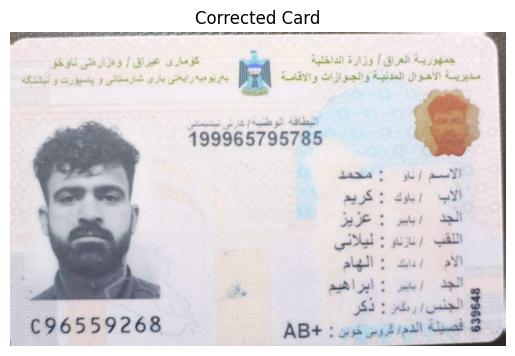

Detected rotation angle: -1.85 degrees
Correcting image with angle: 1.8462194223438089 degrees


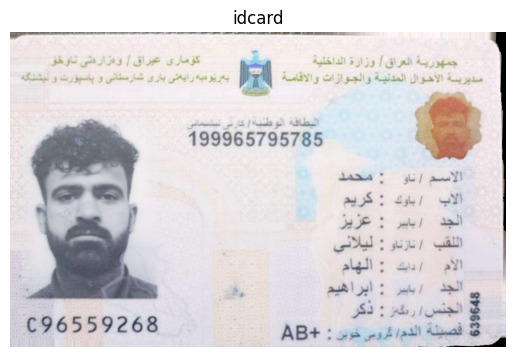

No lines detected with standard parameters, trying alternatives...
Detected rotation angle: 78.40 degrees
Correcting image with angle: 78.40205906122702 degrees


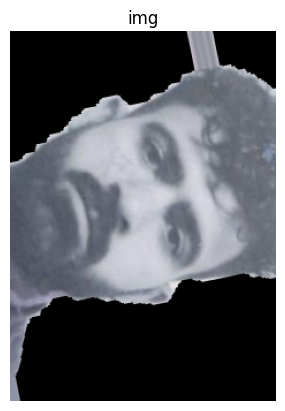

✅ Cropped with padding for idnumber
No lines detected with standard parameters, trying alternatives...
Detected rotation angle: -1.96 degrees
Correcting image with angle: 78.40205906122702 degrees


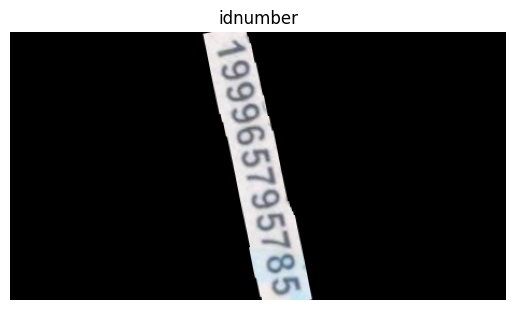

✅ Cropped with padding for name
No lines detected with standard parameters, trying alternatives...
Detected rotation angle: -0.80 degrees
Correcting image with angle: 78.40205906122702 degrees


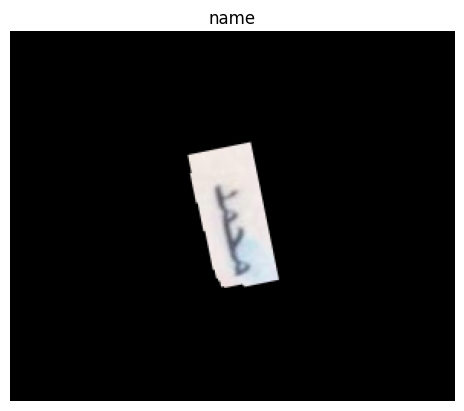

✅ Cropped without padding for blood_group
No lines detected with standard parameters, trying alternatives...
Correcting image with angle: 78.40205906122702 degrees


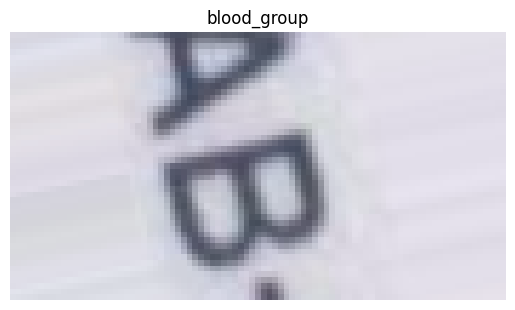

✅ Cropped with padding for jad
No lines detected with standard parameters, trying alternatives...
Detected rotation angle: 0.00 degrees
Correcting image with angle: 78.40205906122702 degrees


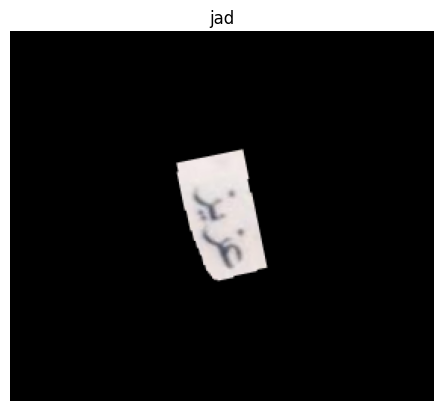

✅ Cropped with padding for father
No lines detected with standard parameters, trying alternatives...
Correcting image with angle: 78.40205906122702 degrees


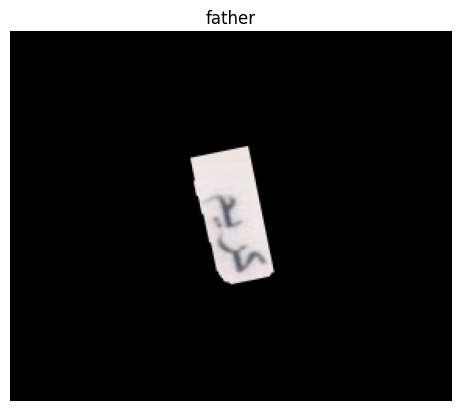

✅ Cropped with padding for laghab
No lines detected with standard parameters, trying alternatives...
Detected rotation angle: 0.00 degrees
Correcting image with angle: 78.40205906122702 degrees


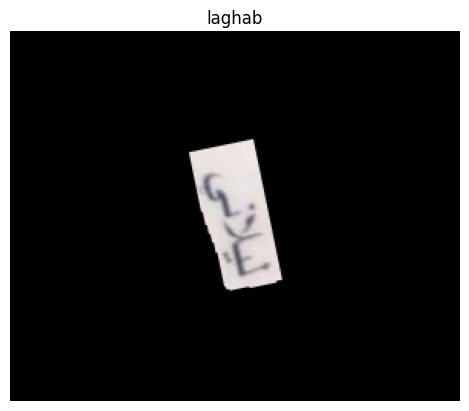

✅ Cropped without padding for gender
No lines detected with standard parameters, trying alternatives...
Correcting image with angle: 78.40205906122702 degrees


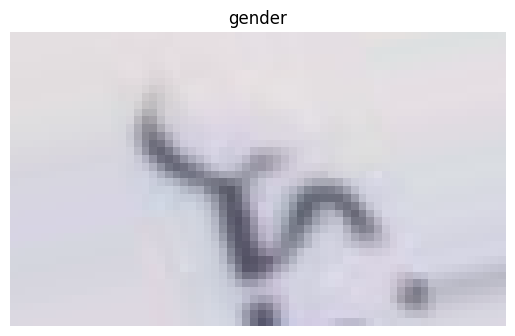

✅ Cropped without padding for mjad
No lines detected with standard parameters, trying alternatives...
Correcting image with angle: 78.40205906122702 degrees


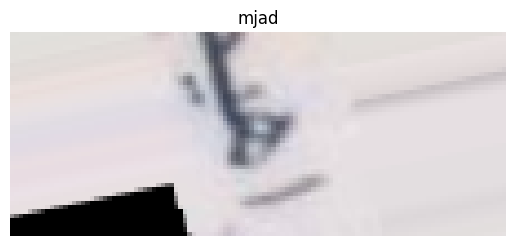

✅ Cropped with padding for mother
No lines detected with standard parameters, trying alternatives...
Detected rotation angle: -0.77 degrees
Correcting image with angle: 78.40205906122702 degrees


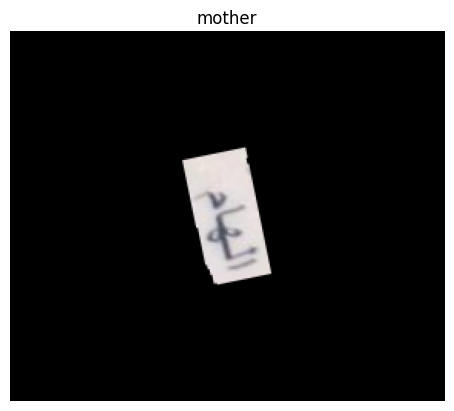

Saved 11 segmented crops to segmented_crops
Saved combined mask to combined_mask.png


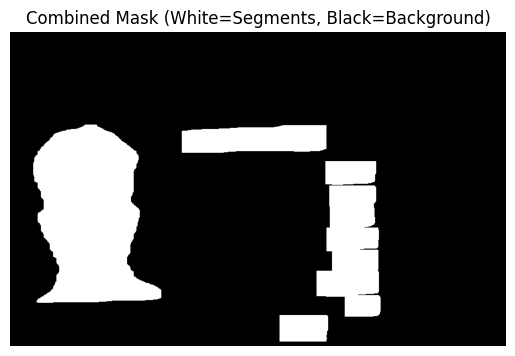

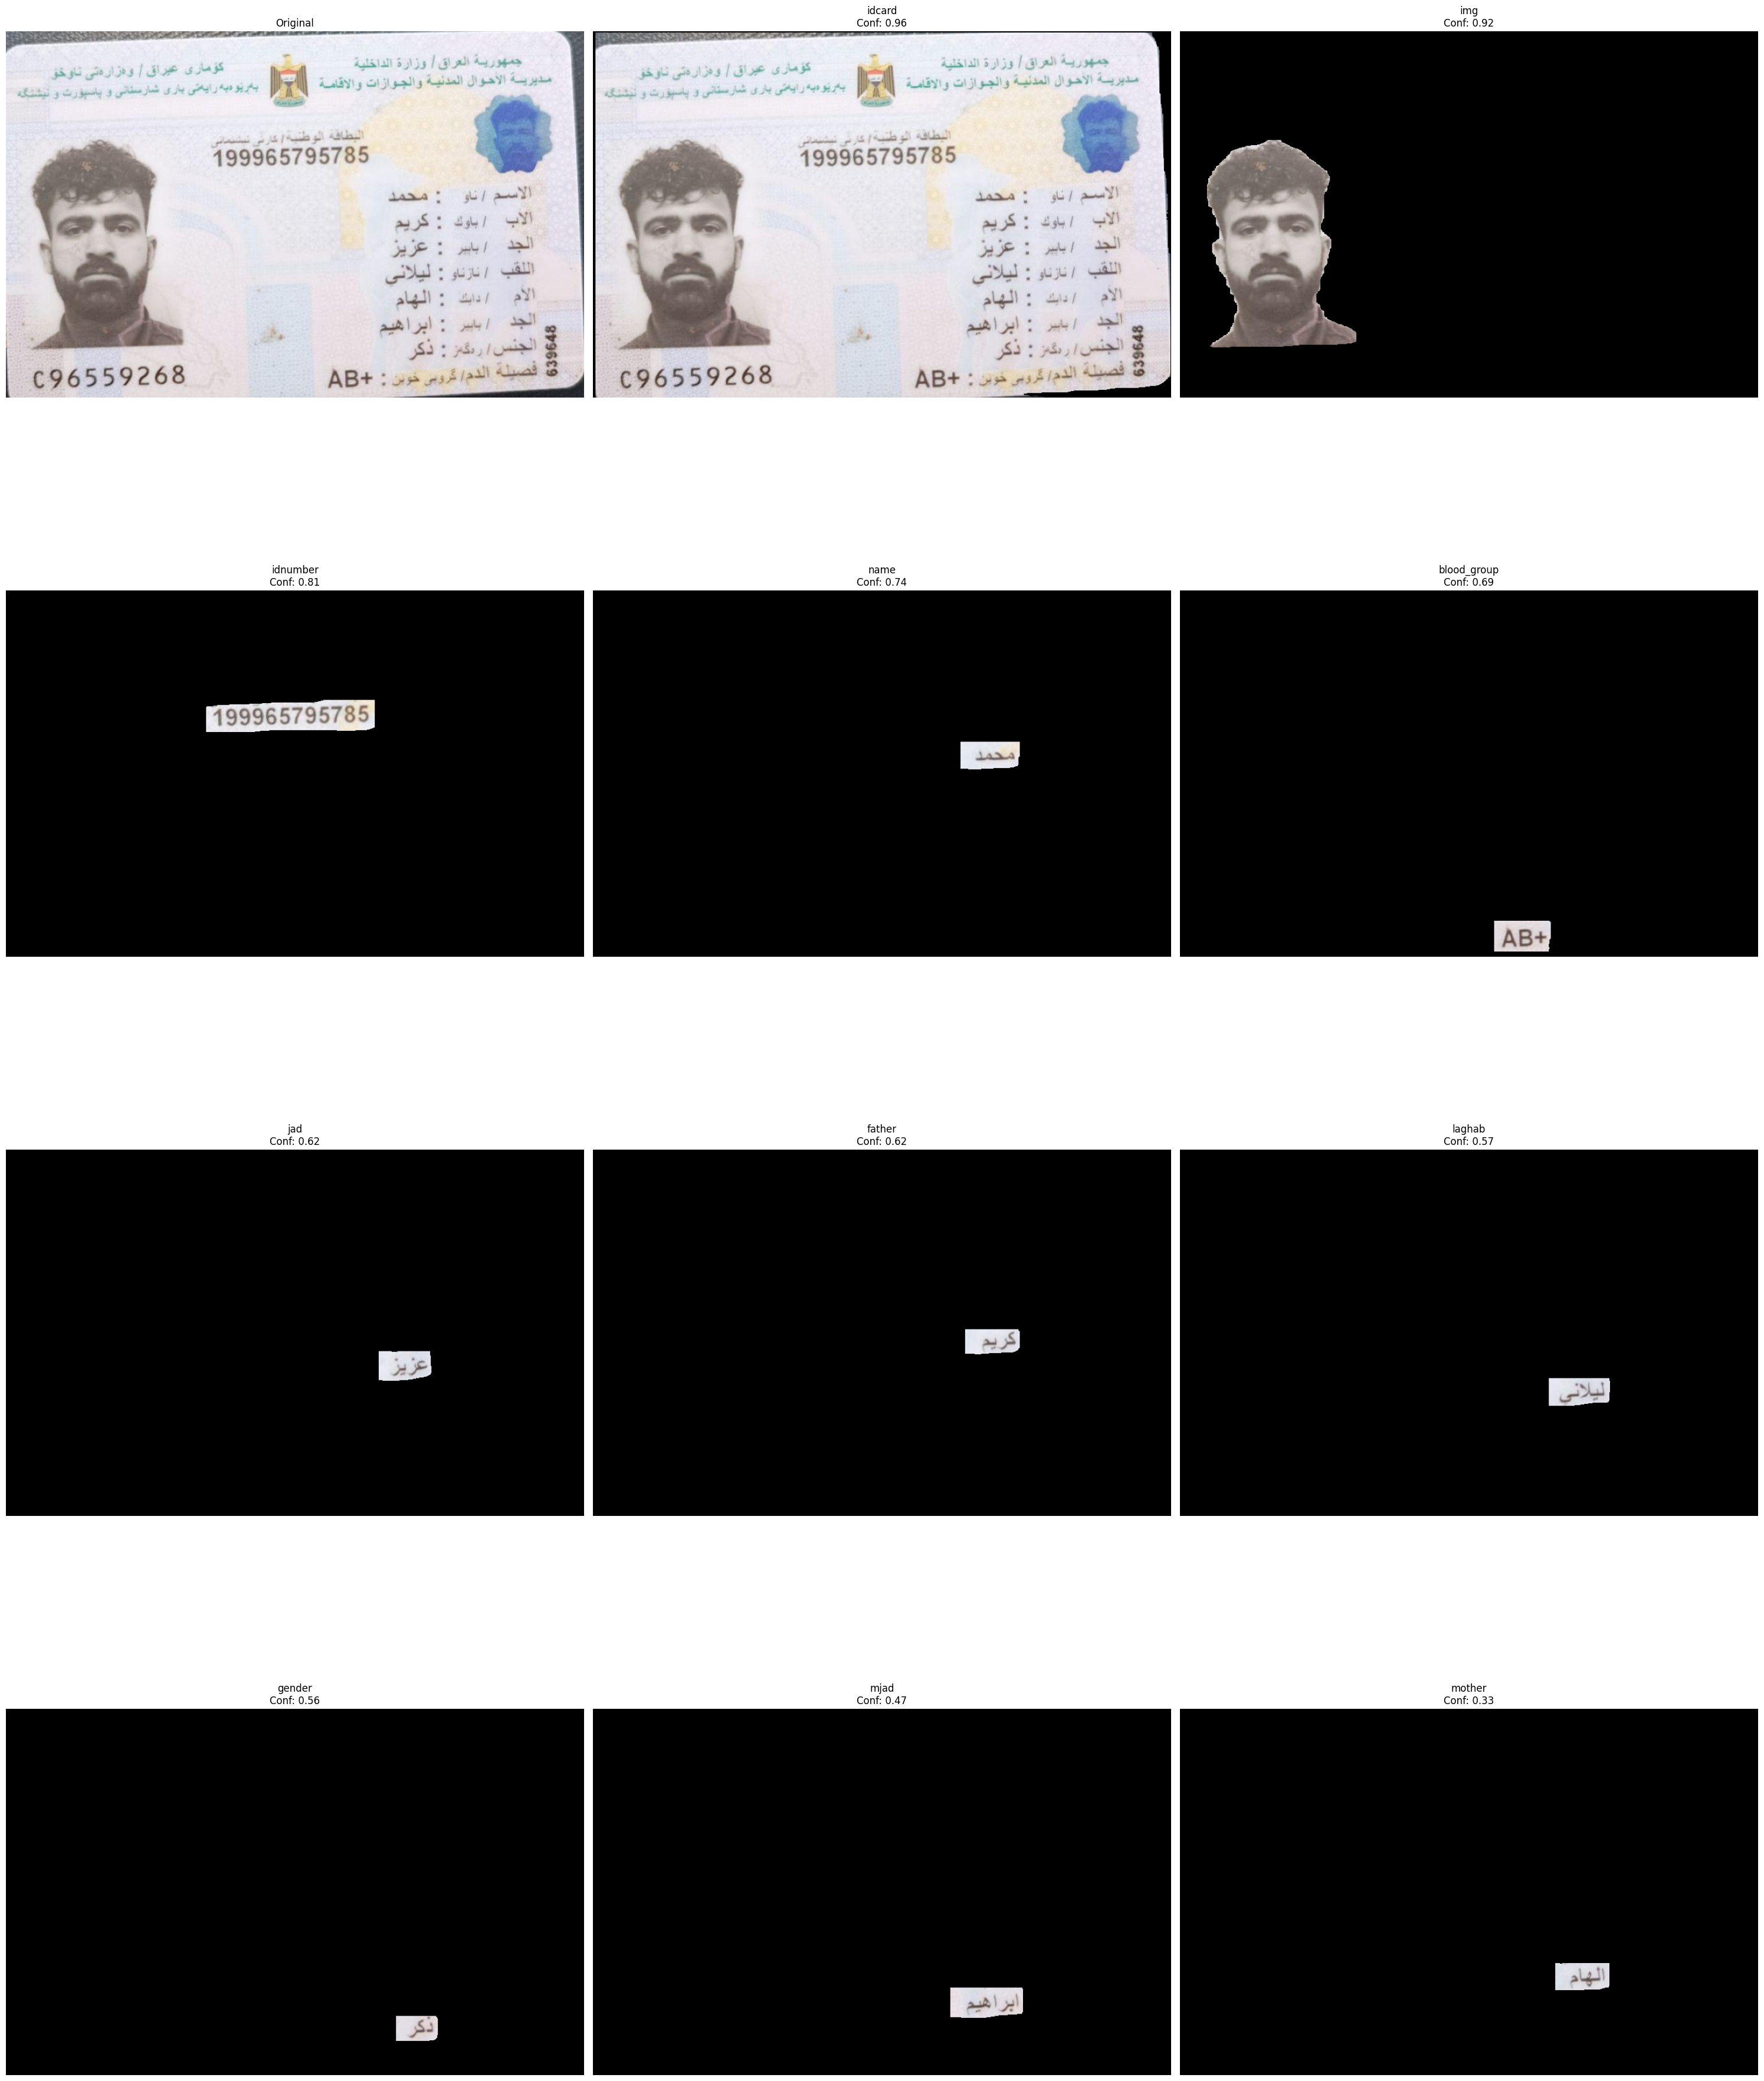

In [10]:
input_path = "/kaggle/input/my-img/mm.jpg"
image,detections,a1=textcropped(model,input_path)
# image,detections,a1=textcroppedidcard(model,input_path,output_crops_dir="segmented_cropsidcard")
plot_detailed_segments(image, detections, classes)

class_name     ::: idcard
without paddd
----------------------
segmented_crops0/idcard.png


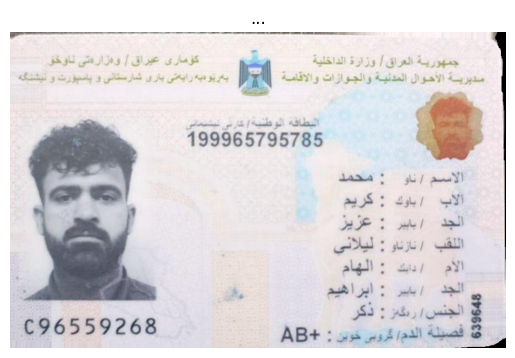

class_name     ::: img
without paddd
----------------------
segmented_crops0/img.png


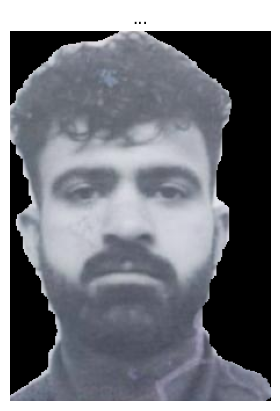

class_name     ::: idnumber
padding
----------------------
segmented_crops0/idnumber.png


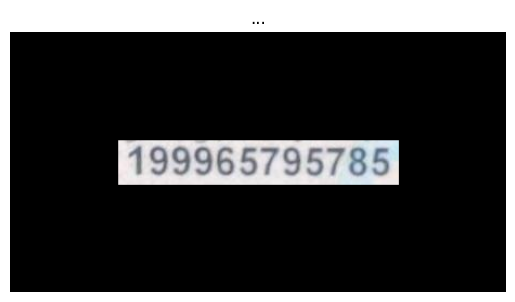

class_name     ::: name
padding
----------------------
segmented_crops0/name.png


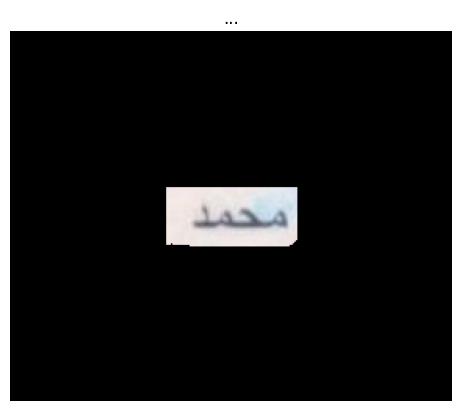

class_name     ::: blood_group
withouth paddd
----------------------
segmented_crops0/blood_group.png


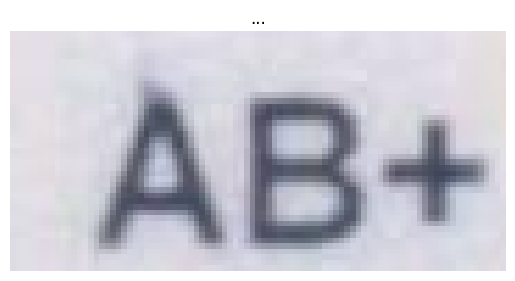

class_name     ::: father
padding
----------------------
segmented_crops0/father.png


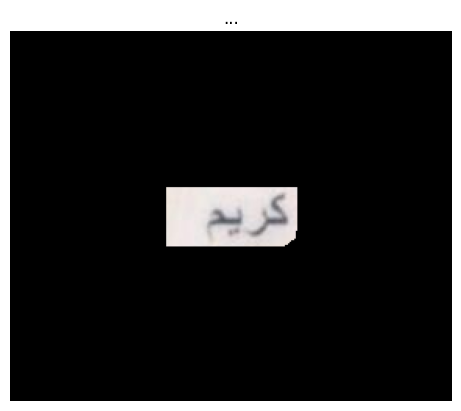

class_name     ::: jad
padding
----------------------
segmented_crops0/jad.png


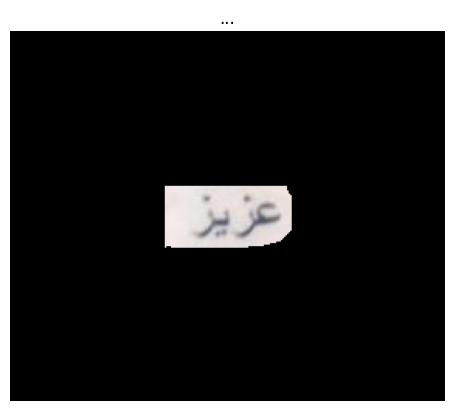

class_name     ::: laghab
padding
----------------------
segmented_crops0/laghab.png


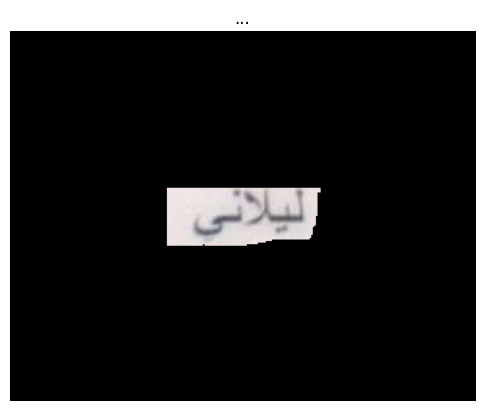

class_name     ::: gender
withouth paddd
----------------------
segmented_crops0/gender.png


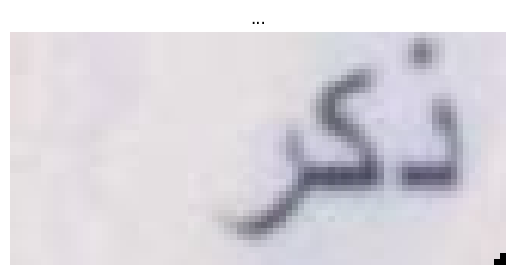

class_name     ::: mother
padding
----------------------
segmented_crops0/mother.png


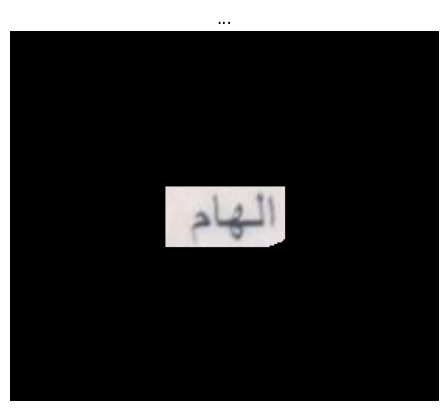

class_name     ::: mjad
withouth paddd
----------------------
segmented_crops0/mjad.png


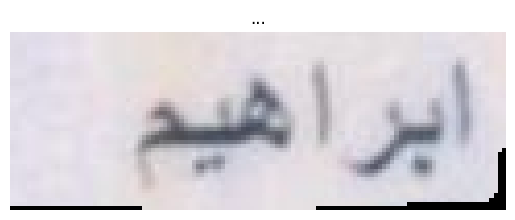

Saved 11 segmented crops to segmented_crops0
Saved combined mask to combined_mask0.png


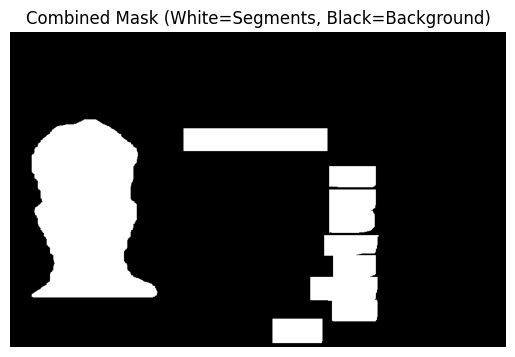

In [11]:
input_path = "/kaggle/working/segmented_crops/idcard.png"
# input_path = "/kaggle/working/segmented_cropsidcard/idcard.png"
image0,detections0=textcropped0(model,input_path,output_crops_dir="segmented_crops0")
# image0,detections0=textcropped(model,input_path,output_crops_dir="segmented_crops0")

# plot_detailed_segments(image, detections, classes)

In [12]:
!pip install realesrgan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 k

In [13]:
file_path = '/usr/local/lib/python3.11/dist-packages/basicsr/data/degradations.py'

# Step 2: Read the file and modify the import statement
with open(file_path, 'r') as file:
    lines = file.readlines()

# Step 3: Modify the specific line
for i, line in enumerate(lines):
    if "from torchvision.transforms.functional_tensor import rgb_to_grayscale" in line:
        lines[i] = line.replace("from torchvision.transforms.functional_tensor import rgb_to_grayscale", "from torchvision.transforms.functional import rgb_to_grayscale")

# Step 4: Write the modified lines back to the file
with open(file_path, 'w') as file:
    file.writelines(lines)

print("Import statement modified successfully.")

Import statement modified successfully.


In [14]:

import cv2
import torch
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

# -----------------------------
# پیکربندی مدل
# -----------------------------
model = RRDBNet(
    num_in_ch=3, 
    num_out_ch=3, 
    num_feat=64,
    num_block=23, 
    num_grow_ch=32, 
    scale=4
)

upscaler = RealESRGANer(
    scale=4,
    model_path='/kaggle/input/preprocessingmodel/pytorch/default/1/RealESRGAN_x4plus.pth',  # مسیر مدل
    model=model,
    tile=0,      # اگر GPU ضعیف داری می‌تونی عدد 100 یا 200 بزاری
    tile_pad=10,
    pre_pad=0,
    half=False,
    device='cpu'# اگر کارت گرافیکت CUDA داره و FP16 ساپورت می‌کنه، می‌تونی True بزاری
)

In [ ]:
# ==================== مثال استفاده ====================
image_path = "/kaggle/working/segmented_crops/idcard.png"
output_path='/kaggle/working/t.jpg'
img = cv2.imread(image_path, cv2.IMREAD_COLOR)
output, _ = upscaler.enhance(img, outscale=4)

cv2.imwrite(output_path, output)
print(f"[INFO] تصویر Upscale شده ذخیره شد: {output_path}")

# yolo for detect 5 0 

In [ ]:
# import os
# import matplotlib.pyplot as plt
# import cv2
# import numpy as np
# import supervision as sv
# from roboflow import Roboflow
# from PIL import Image

# def loadyolo_05(api_key="XNjXPo3HTc0NFRVrH8Kz",pn="numbersdetection-qtmhj"):
#     # Initialize Roboflow segmentation model
#     rf = Roboflow(api_key)
#     project = rf.workspace().project(pn)
#     version = project.version(5)
#     model = version.model
#     return model

    
# # -----------------------------
# # تابع تغییر اندازه برای جلوگیری از ارور 413
# # -----------------------------
# def resize_image05(image_path, output_path, max_size=2048):
#     img = Image.open(image_path)
#     img.thumbnail((max_size, max_size))
#     img.save(output_path)

# # -----------------------------
# # لود مدل Roboflow
# # -----------------------------
# model05=loadyolo_05(api_key="XNjXPo3HTc0NFRVrH8Kz",pn="numbersdetection-qtmhj")
# # -----------------------------
# def detect05fromyolo(model05,input_path ): 
    
#     resized_path = "resized_sample0.jpg"
#     resize_image05(input_path, resized_path)
#     # نام کلاس‌ها
#     classes = ['0', '5']
#     # Get predictions
#     result = model05.predict(resized_path, confidence=40).json()
#     # result = model.predict(input_path, confidence=50).json()
#     detections = sv.Detections.from_inference(result) 
    
#     # بارگذاری تصویر
#     image = cv2.imread(resized_path)
    
#     # ابزار کشیدن کادر
#     label_annotator = sv.LabelAnnotator()
#     box_annotator = sv.BoxAnnotator()
    
#     # متن هر باکس
#     labels = [
#         f"{classes[class_id]} ({conf:.2f})"
#         for class_id, conf in zip(detections.class_id, detections.confidence)
#     ]
    
#     # ترسیم روی تصویر
#     annotated_image = box_annotator.annotate(
#         scene=image.copy(),
#         detections=detections
#     )
#     annotated_image = label_annotator.annotate(
#         scene=annotated_image,
#         detections=detections,
#         labels=labels
#     )
    
#     # نمایش با matplotlib
#     plt.figure(figsize=(8, 8))
#     plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
#     plt.axis("off")
#     plt.show()
#     class_names=[]
#     # چاپ جزئیات
#     for i, (class_id, confidence) in enumerate(zip(detections.class_id, detections.confidence)):
#         class_name = classes[class_id] if class_id is not None else f"unknown_{i}"
#         print(f"[{i}] Class: {class_name}, Confidence: {confidence:.2f}")
#         class_names.append(class_name)
    
#     textyolo=class_names
#     print("*****len txt 05")
#     print(len(textyolo))
#     # print('textyolo',textyolo[0])
#     return textyolo

# easy 


In [ ]:
def arabic_indic_to_qwerty(s: str) -> str:
    # Map Arabic-Indic digits to ASCII digits
    trans = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789")
    return s.translate(trans)

def parse_date_arabic_indic(s: str):
    # Convert and split
    normalized = arabic_indic_to_qwerty(s)
    parts = normalized.split("/")
    # Optionally convert parts to ints
    numbers = [int(p) for p in parts if p.isdigit()]
    return normalized, numbers

# def joinyolo05_easyresult(texteasy,txtyolo):
#     print("txtyolo",txtyolo)
#     print("texteasy",texteasy)
#     normalized, numbers = parse_date_arabic_indic(texteasy)
#     # for text in texteasy:
#     #     print('text',text)
#     fixed_text = ""
#     i=0
#     for char in normalized:
#         if char== '0' or char =='5':
#             detected_classes =txtyolo[i] 
#             char=detected_classes
#             i=i+1
#         fixed_text += char
#     print("✅ متن اصلاح‌شده:", fixed_text)
#     return fixed_text
 


# pyteseract

In [ ]:
!apt-get install tesseract-ocr -y
!apt-get install libtesseract-dev -y
!apt-get install tesseract-ocr_FAR -y
!pip install pytesseract
import os

# Create the tessdata directory if it doesn't exist
os.makedirs('/kaggle/working/tessdata', exist_ok=True)

# Download the Persian trained data
!wget -O /kaggle/working/tessdata/fas.traineddata https://github.com/tesseract-ocr/tessdata/raw/main/fas.traineddata
!mkdir -p /kaggle/working/tessdata
!wget https://github.com/tesseract-ocr/tessdata_best/raw/main/eng.traineddata -O /kaggle/working/tessdata/eng.traineddata
import os

# Set TESSDATA_PREFIX to the directory containing tessdata
os.environ['TESSDATA_PREFIX'] = '/kaggle/working/'
import os
from PIL import Image
import pytesseract

# Path to the Tesseract executable
# (In Kaggle, Tesseract is usually at /usr/bin/tesseract)
pytesseract.pytesseract.tesseract_cmd = "/usr/bin/tesseract"

# Path to tessdata directory
tessdata_dir = '/kaggle/working/tessdata'

# Prepare environment variable
os.environ['TESSDATA_PREFIX'] = '/kaggle/working/'

# Verify files
print('TESSDATA_PREFIX:', os.environ['TESSDATA_PREFIX'])
print('Files in tessdata directory:', os.listdir(tessdata_dir))


# Run OCR with explicitly passing the config to specify the data directory
custom_config = f'--tessdata-dir {tessdata_dir}'

# Copy a single file
!cp /kaggle/input/resize46/pytorch/default/1/resized_allimages46.traineddata /kaggle/working/tessdata/resized_allimages46.traineddata


In [ ]:
def pyteseractExtractor(img_path):

    print('pyyyyyyyyyyyyyyytttttteesssarct')
    # Load your image
    # img_path = '/kaggle/working/outputs/birthday.png'
    img = Image.open(img_path)
    
    try:
        text = pytesseract.image_to_string(img, lang='resized_allimages46', config=custom_config)
        print('OCR result:', text)
        plt.figure(figsize=(5, 5))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    except Exception as e:
        print('Error during OCR:', e)
    return text

# **easyocr**

# methodes for easyocr

In [ ]:

import easyocr
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import os
import json
import cv2    
import numpy as np   
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm  # برای نمایش پیشرفت آموزش
 
import matplotlib.pyplot as plt

# 1. تنظیم مسیرهای مدل
def loadeasyocr(MODEL_DIR = './models'):
    # MODEL_DIR = '/kaggle/working/models'  # یا هر مسیر دلخواه
    os.makedirs(MODEL_DIR, exist_ok=True)
    
    # 2. دانلود و بارگذاری مدل فارسی
    try:
        reader = easyocr.Reader(
            # lang_list=['ar'],
            lang_list=['fa'],
            gpu=True,  # یا False اگر GPU ندارید
            model_storage_directory=MODEL_DIR,
            download_enabled=True,
            recognizer=True,
            detector=True
        )
        print("مدل فارسی با موفقیت بارگذاری شد!")
    except Exception as e:
        print(f"خطا در بارگذاری مدل: {e}")
        raise
    print("mode is ready....")
    return reader


# 3. تابع بهبود یافته برای تست
def improved_test(reader , image_path):
    # print("start...")
    text=''
    try:
        # print("read..")
        # خواندن تصویر
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"نمی‌توان تصویر {image_path} را خواند")
            
        # تشخیص متن
        results = reader.readtext(
            image_path,
            decoder='beamsearch',
            beamWidth=5,
            batch_size=4,
            detail=1
        )
        
        # نمایش نتایج
        plt.figure(figsize=(5, 5))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        
        if not results:
            print("هیچ متنی تشخیص داده نشد!")
            return
            
        print(f"\nنتایج برای {image_path}:")
        for (bbox, textt, prob) in results:
            print(f"- متن: {textt} (اعتماد: {prob:.2f})")
            text=text+' '+textt
            # رسم مستطیل دور متن
            cv2.rectangle(img, 
                         tuple(map(int, bbox[0])), 
                         tuple(map(int, bbox[2])), 
                         (0, 255, 0), 2)
        
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"خطا در پردازش تصویر {image_path}: {e}")
    return text

def resize_imageeasy(image_path, output_path, max_size=2048):
    img = Image.open(image_path)
    img.thumbnail((max_size, max_size))
    img.save(output_path)

import cv2

def preprocess_for_ocr_color_smooth(input_path, output_path=None, upscale=2):
    """
    Preprocess cropped ID card images while keeping colors.
    - نگه داشتن تصویر رنگی
    - بزرگ‌نمایی
    - شارپ‌سازی + صاف کردن نویز بک‌گراند
    """
    # 1. خواندن تصویر رنگی
    img = cv2.imread(input_path)
    if img is None:
        raise ValueError(f"تصویر {input_path} یافت نشد!")

    # 2. بزرگ‌نمایی
    h, w, c = img.shape
    img = cv2.resize(img, (w*upscale, h*upscale), interpolation=cv2.INTER_CUBIC)

    # 3. صاف کردن نویز (Bilateral Filter → حفظ لبه‌ها + حذف بک‌گراند)
    smooth = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

    # 4. شارپ‌سازی بعد از صاف کردن
    blur = cv2.GaussianBlur(smooth, (3,3), 0)
    sharpened = cv2.addWeighted(smooth, 1.3, blur, -0.3, 0)

    # 5. ذخیره اگر خواستی
    if output_path:
        cv2.imwrite(output_path, sharpened)

    return output_path


def preprocess_for_ocr(input_path, output_path=None, upscale=2):
    
    img = cv2.imread(input_path)
    if img is None:
        raise ValueError(f"تصویر {input_path} یافت نشد!")

    # 2. بزرگ‌نمایی
    h, w, c = img.shape
    img = cv2.resize(img, (w*upscale, h*upscale), interpolation=cv2.INTER_CUBIC)

    # 3. شارپ‌سازی (Unsharp Mask)
    blur = cv2.GaussianBlur(img, (3,3), 0)
    sharpened = cv2.addWeighted(img, 1.5, blur, -0.5, 0)

    # 4. ذخیره اگر مسیر داده شده باشد
    if output_path:
        cv2.imwrite(output_path, sharpened)
    return output_path



def extractinfoIdcard(reader,ImageSegmentsfolder = "./segmented_crops" ):
    folder=ImageSegmentsfolder
    # 4. تست روی نمونه‌ها
    my_datajason={}
    
    tempresize = "temp.jpg"

    
    # folder = "./segmented_crops"  # adjust
    files = []
    for dirpath, dirnames, filenames in os.walk(folder):
        for name in filenames:
            files.append(os.path.join(dirpath, name))
    
    # print or save
    for i, (img_path, fn) in enumerate(zip(files, filenames)):
        print(files)
        if not os.path.exists(img_path):
            print(f"تصویر {img_path} یافت نشد!")
            continue
            
        resize_imageeasy(img_path, tempresize) 
        
        # imm = preprocess_for_ocr(tempresize,tempresize)
        # resize_imageeasy(tempresize, tempresize)
        
        
        # if (fn=="idnumber.png" or fn=="idnumber.jpg"):
        #     model05=loadyolo_05(api_key="XNjXPo3HTc0NFRVrH8Kz",pn="numbersdetection-qtmhj") 
        #     txt05=detect05fromyolo(model05,img_path)
        #     texteasy=joinyolo05_easyresult(texteasy,txt05)
        # if (fn=="birthday.png" or fn=="exp.png" or fn=="birthday.jpg" or fn=="exp.jpg"):
        if (fn=="birthday.png" or fn=="exp.png" or fn=="idnumber.png" or fn=="birthday.jpg" or fn=="exp.jpg" or fn=="idnumber.jpg"):
            # model05=loadyolo_05(api_key="XNjXPo3HTc0NFRVrH8Kz",pn="numbersdetection-qtmhj") 
            # txt05=detect05fromyolo(model05,img_path)
            # texteasy=joinyolo05_easyresult(texteasy,txt05)
            print("hiii pytesseract")
            # t=preprocess_for_ocr(img_path, output_path='t.jpg')
            t=preprocess_for_ocr_color_smooth(img_path, output_path='t.jpg')
            
            
            textpytesseract=pyteseractExtractor(t)
            # textpytesseract=pyteseractExtractor(tempresize)
            # textpytesseract=pyteseractExtractor(img_path)
            texteasy=textpytesseract
            print("hiii easssss:")
            print(texteasy)
        else:   
            # t=preprocess_for_ocr(img_path, output_path='t.jpg')
            t=preprocess_for_ocr_color_smooth(img_path, output_path='t.jpg')
            texteasy=improved_test(reader,t)
            # texteasy=improved_test(reader,tempresize)
            # texteasy=improved_test(reader,img_path)
        # Add a new text field
        
        if (fn=="img.png" or fn=="idcard.png" or fn=="img.jpg" or fn=="idcard.jpg"):
            my_datajason[fn] = img_path
            
        else:
            my_datajason[fn] = texteasy
        
    # return_json = json.dumps(my_data)  # compact representation
    # # Or pretty-printed
    # return_json_pretty = json.dumps(my_data, indent=4)
    
    # print(return_json)
    # print(return_json_pretty)
    return my_datajason
    

# run easyocr to extract text of IDcard

In [ ]:
import os
import json

reader=loadeasyocr(MODEL_DIR = '/kaggle/working/models')


In [ ]:
# ImageSegmentsfolder="/kaggle/input/mohamadid"
ImageSegmentsfolder="./segmented_crops0"
# +++ This is  ./segmented_crops  is very better than ./segmented_crops0. so continue wth ./segmented_crops.
# ImageSegmentsfolder= "./segmented_crops"

jasonText=extractinfoIdcard(reader,ImageSegmentsfolder)
print(jasonText)


# post Peocessing

In [ ]:
key_to_farsi = {
    'idnumber.png': 'کد_ملی',
    'name.png': 'نام',
    'lastname.png': 'نام_خانوادگی',
    'fathername.png': 'نام_پدر',
    'birthday.png': 'تاریخ_تولد',
    'exp.png': 'تاریخ_اعتبار',
    'img.png': 'عکس',
    'idcard.png': 'کارت_ملی'
}

# تبدیل کلیدها به کلیدهای فارسی همراه با مقدار اصلی
translated = { key_to_farsi.get(k, k): v for k, v in jasonText.items() }
translated = json.dumps(translated, ensure_ascii=False, indent=4)
print(translated)

### run for a part ot image(like just name)

In [ ]:
# # مسیر ورودی/خروجی تصویر
# input_path = '/kaggle/input/my-img/nnn.jpg'
# # input_path ='/kaggle/input/my-img/5963104161539147056.jpg'
# output_patheasy = "/kaggle/working/img.jpg"
# resize_imageeasy(input_path, output_patheasy)
# texteasy=improved_test(reader,output_patheasy)
# # improved_test(input_path)
# print('texteasy',texteasy)
# print('done!')

## mask on id card

In [ ]:
# # input_path = "/kaggle/input/zh-img/5863846634104933535.jpg"
# input_path ='/kaggle/input/zh-img/58617498224810914006.jpg'

# image,detections,a1=textcropped(model,input_path)
# plot_detailed_segments(image, detections, classes)

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

def extract_fields(card, mask, field_names, output_dir="outputs", visualize=True):
    """
    کارت ملی کراپ‌شده و ماسک فیلدها را گرفته و 
    فیلدها را جدا کرده و ذخیره می‌کند.
    
    ورودی‌ها:
        card: تصویر کارت (BGR)
        mask: تصویر ماسک (Gray)
        field_names: لیست نام فیلدها
        output_dir: مسیر ذخیره
        visualize: اگر True باشد کراپ‌ها را نمایش می‌دهد
    
    خروجی:
        dict شامل نام فیلد → مسیر ذخیره‌شده
    """
    os.makedirs(output_dir, exist_ok=True)

    # پیدا کردن کانتورهای ماسک
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # تقسیم به چپ و راست
    img_contour = None
    right_contours = []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if x < card.shape[1] // 2:  # سمت چپ (img)
            img_contour = c
        else:  # سمت راست
            right_contours.append(c)

    # مرتب‌سازی راست‌ها از بالا به پایین
    right_contours = sorted(right_contours, key=lambda c: cv2.boundingRect(c)[1])

    # ترتیب نهایی
    final_contours = []
    if img_contour is not None:
        final_contours.append(img_contour)
    final_contours.extend(right_contours)

    print(f"✅ تعداد فیلدهای پیدا شده: {len(final_contours)}")

    results = {}

    # کراپ و ذخیره فیلدها
    for i, contour in enumerate(final_contours):
        x, y, w, h = cv2.boundingRect(contour)
        crop = card[y:y+h, x:x+w]

        # انتخاب نام
        if i < len(field_names):
            name = field_names[i]
        else:
            name = f"field_{i}"

        save_path = os.path.join(output_dir, f"{name}.png")
        cv2.imwrite(save_path, crop)
        results[name] = save_path

        if visualize:
            plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            plt.title(name)
            plt.axis("off")
            plt.show()

        print(f"💾 ذخیره شد: {save_path}")

    return results
# extract_fields(card, mask, field_names, output_dir="outputs", visualize=False)

In [ ]:
import cv2
import numpy as np
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


# اسم فیلدها به ترتیب از بالا به پایین (طبق ماسک)
# field_names = [
#     "عکس",
#     "کدملی",
#     "نام",
#     "نام_خانوادگی",
#     "تاریخ_تولد",
#     "نام_پدر",
#     "تاریخ_انقضا"
# ]
field_names = [ "img", "idnumber", "name", "lastname", "birthday", "fathername", "exp"]


# مسیرها
# card_path = input_path   # کارت ملی کراپ‌شده
# input_path = "/kaggle/input/iranian-national-id-card-dataset/sample3.jpg"
card_path = "/kaggle/working/resized_sample.jpg" 
mask_path = "/kaggle/working/combined_mask.png"
# card_path="/kaggle/working/segmented_crops0/idcard.png"
# mask_path = "/kaggle/input/my-img/combined_mask_Fianl_Idcard.png"  

# card_path = "/kaggle/working/resized_sample0.jpg"
# mask_path = "/kaggle/working/combined_mask0.png" # ماسک (با فیلدها)
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)
# کارت و ماسک رو بخون
card = cv2.imread(card_path)
card, final_angle_corrected = correct_skew_with_negative_angle(card, a1)
       
plt.imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
plt.title("Aligned Card")
plt.axis("off")
plt.show()

mask0 = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

mask0, final_angle_corrected = correct_skew_with_negative_angle(mask0, a1)
plt.imshow(cv2.cvtColor(mask0, cv2.COLOR_BGR2RGB))
plt.title("Aligned mask")
plt.axis("off")
plt.show()
# ماسک رو به سایز کارت resize کن
mask = cv2.resize(mask0, (card.shape[1], card.shape[0]))
# mask=mask0 
plt.imshow(cv2.cvtColor(mask, cv2.COLOR_BGR2RGB))
plt.title("Aligned mask")
plt.axis("off")
plt.show()


extract_fields(card, mask, field_names, output_dir="outputs", visualize=True)

# # پیدا کردن کانتورهای ماسک (هر فیلد یک کانتور سفید)
# contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # کانتورها رو از بالا به پایین مرتب کن
# contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])

# # بررسی تعداد کانتورها
# print(f"✅ تعداد فیلدهای پیدا شده در ماسک: {len(contours)}")

# # کراپ و ذخیره‌ی هر فیلد
# for i, contour in enumerate(contours):
#     x, y, w, h = cv2.boundingRect(contour)

#     # کراپ فیلد از کارت
#     crop = card[y:y+h, x:x+w]
    

#     # نام فایل (اگر تعداد کانتورها بیشتر از لیست بود، شماره بزنیم)
#     if i < len(field_names):
#         name = field_names[i]
#     else:
#         name = f"field_{i}"

#     save_path = os.path.join(output_dir, f"{name}.png")
#     cv2.imwrite(save_path, crop)

#     # output_patheasy = save_path
#     # resize_imageeasy(save_path, output_patheasy)
#     # texteasy=improved_test(reader,output_patheasy)
#     # improved_test(input_path)
#     # print('texteasy',texteasy)
#     print("***********************************************")
    
#     plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
#     plt.title("Aligned Card")
#     plt.axis("off")
#     plt.show()
#     print(f"💾 ذخیره شد: {save_path}")
    
             


In [ ]:
ImageSegmentsfolder="./outputs"
# ImageSegmentsfolder="./segmented_crops"
jasonText=extractinfoIdcard(reader,ImageSegmentsfolder)

print(jasonText)


In [ ]:
key_to_farsi = {
    'idnumber.png': 'کد_ملی',
    'name.png': 'نام',
    'lastname.png': 'نام_خانوادگی',
    'fathername.png': 'نام_پدر',
    'birthday.png': 'تاریخ_تولد',
    'exp.png': 'تاریخ_اعتبار',
    'img.png': 'عکس',
    'idcard.png': 'کارت_ملی'
}

# تبدیل کلیدها به کلیدهای فارسی همراه با مقدار اصلی
translated = { key_to_farsi.get(k, k): v for k, v in jasonText.items() }
translated = json.dumps(translated, ensure_ascii=False, indent=4)
print(translated)

نکته:
*  اگر با عکس اولیه کار کنیم، ماسک ریز ، کانتورها غیر قابل تشخیص-> کراپ کینم عکس و کانتور را
*  اگر با عکس ای دی کارت کار کنیم و با ماسکش، بعضی کانتور ها را تشخیص نمیدهد و اسامی را خوب رید نمیکند به دلیل زوم آنها شاید، -< یولو را با عکسه ای زوم شده ی بیشتری ترین کنیم. و برای زوم اسامی، پای تسرکت را با این اسامی ترین کنیم. ( در دست اجر)
*  اگر اصلا از ماسک استفاده نکنیم،  عکس ها حاشیه ی مواج و مشکلی دارند و ریدر را مخصوصا در اعداد خطا دارند در انها.
*  بهترین راه: گزینه ی 2

##### 

# Dots.ocr LLm

In [ ]:
!git clone https://github.com/saveBro6/dots.ocr_kaggle.git
#!pip install -q torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 --index-url https://download.pytorch.org/whl/cu118
%cd /kaggle/working/dots.ocr_kaggle
!pip install -q -e .
!pip install -q bitsandbytes
!python tools/download_model.py


import os
import torch
from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

# 1. Cấu hình môi trường để chống phân mảnh bộ nhớ
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

model_path = "./weights/DotsOCR"
# image_path = "/kaggle/input/kurdi-namesds/5000data/5000data/0.png"

# Cấu hình Load 4-bit 
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Load Model
print("Loading model with 4-bit quantization...")
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    quantization_config=bnb_config,    # Kích hoạt 4-bit
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
    device_map="balanced_low_0",                 
    trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

# --- TỐI ƯU 3: Resize ảnh đầu vào (Quan trọng cho PDF full trang) ---
def resize_image(image_path, max_size=1280):
    img = Image.open(image_path).convert("RGB")
    width, height = img.size
    # Nếu ảnh quá to, thu nhỏ lại để giảm số lượng token
    if max(width, height) > max_size:
        ratio = max_size / max(width, height)
        new_size = (int(width * ratio), int(height * ratio))
        img = img.resize(new_size, Image.LANCZOS)
        print(f"Resized image from {width}x{height} to {new_size}")
    return img


In [ ]:
image_path = "/kaggle/input/my-img/akb.jpg"
# Load và resize ảnh
pil_image = resize_image(image_path, max_size=1024) # 1024 là mức an toàn cho Kaggle T4

prompt = """Extract the text content from this image."""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": pil_image}, # Truyền ảnh PIL đã resize vào đây
            {"type": "text", "text": prompt}
        ]
    }
]

# Preparation
print("Processing inputs...")
text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

# Logic tìm device tự động (Giữ nguyên logic cũ của bạn vì nó đúng)
if hasattr(model, "get_input_embeddings"):
    target_device = model.get_input_embeddings().weight.device
else:
    target_device = next(model.parameters()).device

inputs = inputs.to(target_device)

# Inference
print("Generating...")
# Giảm max_new_tokens xuống một chút nếu vẫn OOM (ví dụ 2048)
generated_ids = model.generate(**inputs, max_new_tokens=4096)

generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print("Done!")
# print(output_text[0]) # In kết quả
print("Text is : ")
print(output_text[0]) # In kết quả